In [10]:
import pandas as pd

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [11]:
missing_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']

print(df[missing_cols].describe())

            Tenure  WarehouseToHome  HourSpendOnApp  \
count  5366.000000      5379.000000     5375.000000   
mean     10.189899        15.639896        2.931535   
std       8.557241         8.531475        0.721926   
min       0.000000         5.000000        0.000000   
25%       2.000000         9.000000        2.000000   
50%       9.000000        14.000000        3.000000   
75%      16.000000        20.000000        3.000000   
max      61.000000       127.000000        5.000000   

       OrderAmountHikeFromlastYear   CouponUsed   OrderCount  \
count                  5365.000000  5374.000000  5372.000000   
mean                     15.707922     1.751023     3.008004   
std                       3.675485     1.894621     2.939680   
min                      11.000000     0.000000     1.000000   
25%                      13.000000     1.000000     1.000000   
50%                      15.000000     1.000000     2.000000   
75%                      18.000000     2.000000     3.00

In [12]:
# Fix the two anomalous WarehouseToHome values (likely typos: 126->26, 127->27)
df.loc[df['WarehouseToHome'] == 126, 'WarehouseToHome'] = 26
df.loc[df['WarehouseToHome'] == 127, 'WarehouseToHome'] = 27

print(df['WarehouseToHome'].describe())
missing_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']

for col in missing_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val}")

# Verify no more missing values
print(df.isnull().sum())

count    5379.000000
mean       15.602714
std         8.261845
min         5.000000
25%         9.000000
50%        14.000000
75%        20.000000
max        36.000000
Name: WarehouseToHome, dtype: float64
Tenure: filled with median = 9.0
WarehouseToHome: filled with median = 14.0
HourSpendOnApp: filled with median = 3.0
OrderAmountHikeFromlastYear: filled with median = 15.0
CouponUsed: filled with median = 1.0
OrderCount: filled with median = 2.0
DaySinceLastOrder: filled with median = 3.0
CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmou

In [13]:
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus', 'Gender']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--- PreferedOrderCat ---
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

--- Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64



In [14]:

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})


df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})


for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

--- PreferedOrderCat ---
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64



In [15]:
print(df['PreferedOrderCat'].value_counts())
print("Total rows:", len(df))
print("Sum of category counts:", df['PreferedOrderCat'].value_counts().sum())

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64
Total rows: 5630
Sum of category counts: 5630


Churn
0    11.404528
1     3.859705
Name: Tenure, dtype: float64


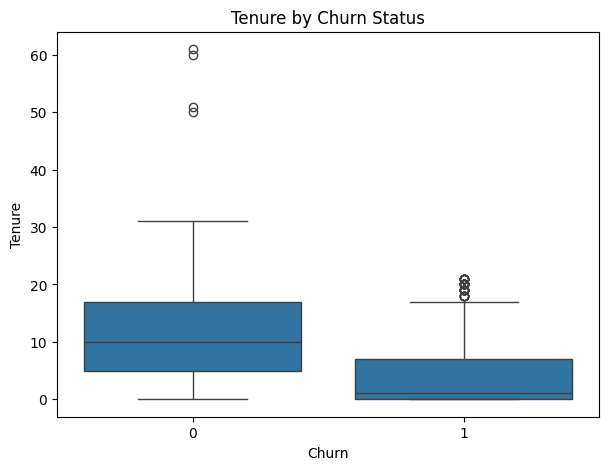

Complain
0    10.928962
1    31.670823
Name: Churn, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.groupby('Churn')['Tenure'].mean())

plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure by Churn Status')
plt.show()

churn_by_complain = df.groupby('Complain')['Churn'].mean() * 100
print(churn_by_complain)

In [17]:
# CashbackAmount
print(df.groupby('Churn')['CashbackAmount'].mean())

# SatisfactionScore
print(df.groupby('Churn')['SatisfactionScore'].mean())

# Churn by PreferedOrderCat
churn_by_cat = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False) * 100
print(churn_by_cat)

Churn
0    180.635203
1    160.370928
Name: CashbackAmount, dtype: float64
Churn
0    3.001282
1    3.390295
Name: SatisfactionScore, dtype: float64
PreferedOrderCat
Mobile Phone          27.403846
Fashion               15.496368
Laptop & Accessory    10.243902
Others                 7.575758
Grocery                4.878049
Name: Churn, dtype: float64


In [18]:
# MaritalStatus
print(df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False) * 100)

# PreferredPaymentMode
print(df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False) * 100)

# NumberOfAddress vs churn
print(df.groupby('Churn')['NumberOfAddress'].mean())

# CityTier vs churn
print(df.groupby('CityTier')['Churn'].mean() * 100)

MaritalStatus
Single      26.726058
Divorced    14.622642
Married     11.520429
Name: Churn, dtype: float64
PreferredPaymentMode
Cash on Delivery    24.902724
E wallet            22.801303
UPI                 17.391304
Debit Card          15.384615
Credit Card         14.205186
Name: Churn, dtype: float64
Churn
0    4.162965
1    4.466245
Name: NumberOfAddress, dtype: float64
CityTier
1    14.511729
2    19.834711
3    21.370499
Name: Churn, dtype: float64


In [19]:

categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                     'PreferedOrderCat', 'MaritalStatus']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


df_encoded = df_encoded.drop('CustomerID', axis=1)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(5630, 26)
['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredLoginDevice_Mobile Phone', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Male', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single']


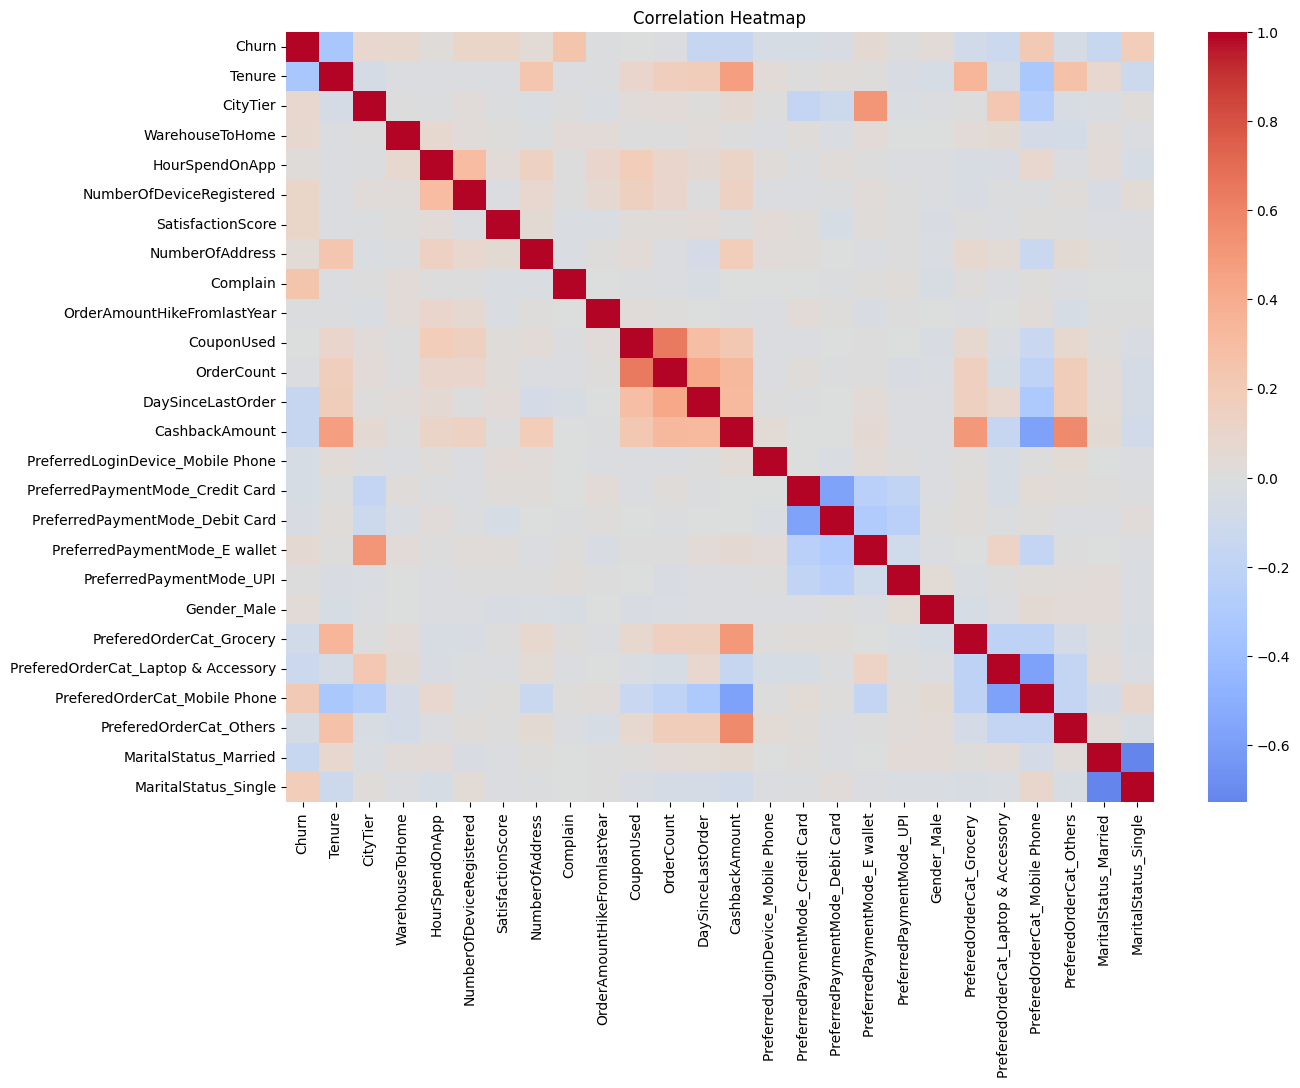

Churn                                  1.000000
Complain                               0.250188
PreferedOrderCat_Mobile Phone          0.216120
MaritalStatus_Single                   0.180847
NumberOfDeviceRegistered               0.107939
SatisfactionScore                      0.105481
CityTier                               0.084703
WarehouseToHome                        0.073790
PreferredPaymentMode_E wallet          0.055751
NumberOfAddress                        0.043931
Gender_Male                            0.029264
HourSpendOnApp                         0.018816
PreferredPaymentMode_UPI               0.004163
CouponUsed                            -0.001430
OrderAmountHikeFromlastYear           -0.007075
OrderCount                            -0.024038
PreferredPaymentMode_Debit Card       -0.032453
PreferredPaymentMode_Credit Card      -0.047728
PreferredLoginDevice_Mobile Phone     -0.051099
PreferedOrderCat_Others               -0.054903
PreferedOrderCat_Grocery              -0

In [20]:

plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


print(df_encoded.corr()['Churn'].sort_values(ascending=False))

In [21]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (4504, 25)
Test shape: (1126, 25)
Train churn rate: 0.16829484902309058
Test churn rate: 0.16873889875666073


In [22]:
print("="*60)
print("CUSTOMER CHURN ANALYSIS - KEY INSIGHTS")
print("="*60)

print(f"\nOverall churn rate: {df['Churn'].mean()*100:.1f}%")

print("\n--- Tenure ---")
print(f"Avg tenure (churned): {df[df['Churn']==1]['Tenure'].mean():.1f} months")
print(f"Avg tenure (retained): {df[df['Churn']==0]['Tenure'].mean():.1f} months")

print("\n--- Complaints ---")
print(f"Churn rate with complaint: {df[df['Complain']==1]['Churn'].mean()*100:.1f}%")
print(f"Churn rate without complaint: {df[df['Complain']==0]['Churn'].mean()*100:.1f}%")

print("\n--- Highest risk order category ---")
print(df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False).head(1)*100)

print("\n--- Marital status ---")
print(df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False)*100)

print("\n--- City tier ---")
print(df.groupby('CityTier')['Churn'].mean()*100)

CUSTOMER CHURN ANALYSIS - KEY INSIGHTS

Overall churn rate: 16.8%

--- Tenure ---
Avg tenure (churned): 3.9 months
Avg tenure (retained): 11.4 months

--- Complaints ---
Churn rate with complaint: 31.7%
Churn rate without complaint: 10.9%

--- Highest risk order category ---
PreferedOrderCat
Mobile Phone    27.403846
Name: Churn, dtype: float64

--- Marital status ---
MaritalStatus
Single      26.726058
Divorced    14.622642
Married     11.520429
Name: Churn, dtype: float64

--- City tier ---
CityTier
1    14.511729
2    19.834711
3    21.370499
Name: Churn, dtype: float64


In [23]:
df.to_csv('cleaned_ecommerce_churn.csv', index=False)

from google.colab import files
files.download('cleaned_ecommerce_churn.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>